In [1]:
# Instalar la librería especializada en Redes Neuronales de Grafos
!pip install torch_geometric

# PASO 1: Importaciones y Carga de Datos

In [2]:
# ==============================================================================
# CELDA 1: CONFIGURACIÓN Y CARGA PARA PYTORCH
# ==============================================================================
import os
import numpy as np
import pandas as pd
import torch
from google.colab import drive

# 1. Conectar a Drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/CICLO_9/Integrador/Entrenamiento_GNN'

# 2. Rutas de los archivos maestros
RUTA_PANEL = os.path.join(BASE_DIR, 'Datos_Procesados', 'tensor_panel_diario.parquet')
RUTA_GRAFO = os.path.join(BASE_DIR, 'Datos_Procesados', 'grafo_edge_index.npz')

# 3. Cargar Datos
print("Cargando el panel espaciotemporal...")
df_panel = pd.read_parquet(RUTA_PANEL)

print("Cargando la topología del mapa (Grafo)...")
grafo_data = np.load(RUTA_GRAFO)
edge_index = grafo_data['edge_index']
edge_weights = grafo_data['edge_weights']

print(f"Panel cargado: {len(df_panel)} filas.")
print(f"Grafo cargado: {edge_index.shape[1]} conexiones entre nodos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando el panel espaciotemporal...
Cargando la topología del mapa (Grafo)...
Panel cargado: 620400 filas.
Grafo cargado: 2000 conexiones entre nodos.


# PASO 2: El "Origami" de Datos (Creando la Matriz 3D)

In [3]:
# ==============================================================================
# CELDA 2: TRANSFORMACIÓN A MATRIZ TRIDIMENSIONAL (3D)
# ==============================================================================
print("Transformando tabla plana a bloque 3D (Días x Nodos x Features)...")

# 1. Asegurar el orden cronológico absoluto
df_panel = df_panel.sort_values(by=['fecha_delito', 'id_nodo'])

# 2. Definir las dimensiones
num_dias = len(df_panel['fecha_delito'].unique())
num_nodos = 400
# Estas son las columnas que la IA usará para aprender
columnas_features = ['conteo_delitos', 'dia_semana', 'es_fin_semana', 'mes_sin', 'mes_cos']
num_features = len(columnas_features)

# 3. Extraer solo los números y hacer el "Origami" (Reshape)
matriz_3d = df_panel[columnas_features].values.reshape(num_dias, num_nodos, num_features)

print("¡Transformación exitosa!")
print(f"Forma de la matriz: {matriz_3d.shape} -> (Días, Nodos, Features)")

Transformando tabla plana a bloque 3D (Días x Nodos x Features)...
¡Transformación exitosa!
Forma de la matriz: (1551, 400, 5) -> (Días, Nodos, Features)


# PASO 3: La Máquina del Tiempo (Ventana Deslizante)

In [4]:
# ==============================================================================
# CELDA 3: GENERADOR DE VENTANAS DESLIZANTES (X e Y)
# ==============================================================================
print("Rebanando el tiempo en ventanas de 14 días...")

VENTANA_DIAS = 14
X_lista = []
Y_lista = []

# Recorremos el calendario hasta que nos queden 14 días de margen
for i in range(num_dias - VENTANA_DIAS):
    # X: Los 14 días de historial (Toda la matriz de features)
    historial_X = matriz_3d[i : i + VENTANA_DIAS, :, :]

    # Y: El día 15. PERO solo nos interesa predecir el 'conteo_delitos' (índice 0),
    # no nos interesa predecir qué día de la semana será mañana.
    respuesta_Y = matriz_3d[i + VENTANA_DIAS, :, 0]

    X_lista.append(historial_X)
    Y_lista.append(respuesta_Y)

# Convertir listas a Tensores de PyTorch
X_tensor = torch.tensor(np.array(X_lista), dtype=torch.float32)
Y_tensor = torch.tensor(np.array(Y_lista), dtype=torch.float32)

print(f"Total de 'Exámenes' generados para la IA: {X_tensor.shape[0]}")
print(f"Forma de X (Preguntas): {X_tensor.shape} -> (Muestras, Días Históricos, Nodos, Features)")
print(f"Forma de Y (Respuestas): {Y_tensor.shape} -> (Muestras, Nodos)")

Rebanando el tiempo en ventanas de 14 días...
Total de 'Exámenes' generados para la IA: 1537
Forma de X (Preguntas): torch.Size([1537, 14, 400, 5]) -> (Muestras, Días Históricos, Nodos, Features)
Forma de Y (Respuestas): torch.Size([1537, 400]) -> (Muestras, Nodos)


# PASO 4: El Corte Cronológico (Train / Test Split)

In [5]:
# ==============================================================================
# CELDA 4: CORTE CRONOLÓGICO Y PREPARACIÓN FINAL
# ==============================================================================
print("Separando datos en Pasado (Entrenamiento) y Futuro (Prueba)...")

total_muestras = X_tensor.shape[0]
limite_train = int(total_muestras * 0.8) # 80% para entrenar

# Los primeros 80% de los datos
X_train = X_tensor[:limite_train]
Y_train = Y_tensor[:limite_train]

# Los últimos 20% de los datos
X_test = X_tensor[limite_train:]
Y_test = Y_tensor[limite_train:]

print("\n--- RESUMEN DE LOS TENSORES DE PYTORCH ---")
print(f"Set de Entrenamiento (Train): {X_train.shape[0]} ventanas.")
print(f"Set de Prueba (Test): {X_test.shape[0]} ventanas.")
print("¡Los datos están 100% listos para inyectarse en la Red Neuronal de Grafos!")

Separando datos en Pasado (Entrenamiento) y Futuro (Prueba)...

--- RESUMEN DE LOS TENSORES DE PYTORCH ---
Set de Entrenamiento (Train): 1229 ventanas.
Set de Prueba (Test): 308 ventanas.
¡Los datos están 100% listos para inyectarse en la Red Neuronal de Grafos!


# PASO 5: Normalización

In [6]:
# ==============================================================================
# CELDA 5: NORMALIZACIÓN (MIN-MAX SCALING SIN DATA LEAKAGE)
# ==============================================================================
from sklearn.preprocessing import MinMaxScaler
import torch

print("Normalizando la variable de delitos (Escala 0 a 1)...")

# 1. Creamos los escaladores
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

# 2. Extraemos SOLO la característica de delitos (índice 0) del set de Entrenamiento
X_train_delitos = X_train[:, :, :, 0].numpy().reshape(-1, 1)
Y_train_delitos = Y_train.numpy().reshape(-1, 1)

# 3. Ajustamos (fit) los escaladores ESTRICTAMENTE con el pasado (Train)
scaler_X.fit(X_train_delitos)
scaler_Y.fit(Y_train_delitos)

# 4. Clonamos los tensores para no dañar los originales
X_train_norm = X_train.clone()
X_test_norm = X_test.clone()

# 5. Transformamos el Train y el Test usando la regla aprendida del pasado
X_train_norm[:, :, :, 0] = torch.tensor(scaler_X.transform(X_train[:, :, :, 0].numpy().reshape(-1, 1)).reshape(X_train[:, :, :, 0].shape), dtype=torch.float32)
X_test_norm[:, :, :, 0] = torch.tensor(scaler_X.transform(X_test[:, :, :, 0].numpy().reshape(-1, 1)).reshape(X_test[:, :, :, 0].shape), dtype=torch.float32)

Y_train_norm = torch.tensor(scaler_Y.transform(Y_train.numpy().reshape(-1, 1)).reshape(Y_train.shape), dtype=torch.float32)
Y_test_norm = torch.tensor(scaler_Y.transform(Y_test.numpy().reshape(-1, 1)).reshape(Y_test.shape), dtype=torch.float32)

print("¡Normalización exitosa!")
print(f"Rango de Y_train crudo: [{Y_train.min():.1f}, {Y_train.max():.1f}] -> Rango Normalizado: [{Y_train_norm.min():.1f}, {Y_train_norm.max():.1f}]")

Normalizando la variable de delitos (Escala 0 a 1)...
¡Normalización exitosa!
Rango de Y_train crudo: [0.0, 15.0] -> Rango Normalizado: [0.0, 1.0]


# PASO 6: Construyendo el "Cerebro": La Arquitectura ST-GNN

In [8]:
# ==============================================================================
# CELDA 6: ARQUITECTURA DE LA RED NEURONAL (ST-GNN) (NO FUNCIONO SIN RAM)
# ==============================================================================
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class RedEspacioTemporal(nn.Module):
    def __init__(self, num_features, unidades_ocultas):
        super(RedEspacioTemporal, self).__init__()

        # 1. Capa Espacial: Entiende el mapa (Grafo)
        self.capa_espacial = GCNConv(num_features, unidades_ocultas)

        # 2. Capa Temporal: Memoria a corto y largo plazo (Secuencia de 14 días)
        # batch_first=True indica que nuestras matrices empiezan por el número de muestras
        self.capa_temporal = nn.GRU(input_size=unidades_ocultas, hidden_size=unidades_ocultas, batch_first=True)

        # 3. Capa de Salida: Convierte el pensamiento de la red en la predicción final (1 número por nodo)
        self.capa_salida = nn.Linear(unidades_ocultas, 1)

    def forward(self, x_ventana, edge_index, edge_weights):
        # x_ventana tiene la forma: [Muestras, 14 Dias, 400 Nodos, 5 Features]
        batch_size, num_dias, num_nodos, num_features = x_ventana.shape

        # Lista para guardar los mapas procesados día por día
        salidas_espaciales = []

        # Procesamos la información espacial de cada uno de los 14 días históricos
        for t in range(num_dias):
            x_dia = x_ventana[:, t, :, :] # Extraemos un día específico

            # Como GCN espera [Nodos, Features], aplanamos momentáneamente
            x_dia_aplanado = x_dia.reshape(-1, num_features)

            # Pasamos por la red de grafos (GCN)
            mapa_procesado = self.capa_espacial(x_dia_aplanado, edge_index, edge_weights)
            mapa_procesado = F.relu(mapa_procesado) # Activación ReLU

            # Recuperamos la forma [Muestras, Nodos, Ocultas]
            mapa_procesado = mapa_procesado.reshape(batch_size, num_nodos, -1)
            salidas_espaciales.append(mapa_procesado)

        # Apilamos los 14 mapas procesados: Forma [Muestras, Nodos, Dias, Ocultas]
        x_secuencia = torch.stack(salidas_espaciales, dim=2)

        # Reordenamos para la capa temporal: [Muestras * Nodos, Dias, Ocultas]
        x_secuencia = x_secuencia.reshape(batch_size * num_nodos, num_dias, -1)

        # Pasamos por la memoria GRU (Solo nos importa la salida del último día)
        _, memoria_final = self.capa_temporal(x_secuencia)
        memoria_final = memoria_final.squeeze(0) # Forma: [Muestras * Nodos, Ocultas]

        # Hacemos la predicción final
        prediccion = self.capa_salida(memoria_final)

        # Le devolvemos la forma [Muestras, Nodos]
        return prediccion.reshape(batch_size, num_nodos)

# Instanciamos el modelo para verificar que compile
modelo_gnn = RedEspacioTemporal(num_features=5, unidades_ocultas=32)
print("¡Arquitectura ST-GNN compilada exitosamente!")
print(modelo_gnn)

¡Arquitectura ST-GNN compilada exitosamente!
RedEspacioTemporal(
  (capa_espacial): GCNConv(5, 32)
  (capa_temporal): GRU(32, 32, batch_first=True)
  (capa_salida): Linear(in_features=32, out_features=1, bias=True)
)


In [7]:
# ==============================================================================
# CELDA 6: ARQUITECTURA ST-GNN (VERSIÓN OPTIMIZADA PARA MEMORIA)
# ==============================================================================
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch

class RedEspacioTemporal(nn.Module):
    def __init__(self, num_features, unidades_ocultas):
        super(RedEspacioTemporal, self).__init__()
        self.capa_espacial = GCNConv(num_features, unidades_ocultas)
        self.capa_temporal = nn.GRU(input_size=unidades_ocultas, hidden_size=unidades_ocultas, batch_first=True)
        self.capa_salida = nn.Linear(unidades_ocultas, 1)

    def forward(self, x_ventana, edge_index, edge_weights):
        batch_size, num_dias, num_nodos, num_features = x_ventana.shape
        salidas_espaciales = []

        # Procesamos día por día
        for t in range(num_dias):
            x_dia = x_ventana[:, t, :, :] # [Batch, Nodos, Features]
            mapas_batch = []

            # Procesamos muestra por muestra en el lote para no saturar la RAM
            for b in range(batch_size):
                out = self.capa_espacial(x_dia[b], edge_index, edge_weights)
                out = F.relu(out)
                mapas_batch.append(out)

            mapa_procesado = torch.stack(mapas_batch) # Volvemos a armar el bloque
            salidas_espaciales.append(mapa_procesado)

        x_secuencia = torch.stack(salidas_espaciales, dim=2)
        x_secuencia = x_secuencia.reshape(batch_size * num_nodos, num_dias, -1)

        _, memoria_final = self.capa_temporal(x_secuencia)
        memoria_final = memoria_final.squeeze(0)

        prediccion = self.capa_salida(memoria_final)
        return prediccion.reshape(batch_size, num_nodos)

modelo_gnn = RedEspacioTemporal(num_features=5, unidades_ocultas=32)
print("¡Arquitectura ST-GNN Anti-Crash compilada exitosamente!")

¡Arquitectura ST-GNN Anti-Crash compilada exitosamente!


# CONVERSIÓN DEL GRAFO A TENSORES ESTRICTOS

In [8]:
# ==============================================================================
# CELDA 6.5: CONVERSIÓN DEL GRAFO A TENSORES ESTRICTOS
# ==============================================================================
print("Convirtiendo el Grafo al formato estricto de PyTorch Geometric...")

# 1. edge_index DEBE ser un tensor de enteros (long) porque son IDs de Nodos (0, 1, 2...)
# Usamos .clone().detach() por si acaso ya era un tensor y no romper la memoria
if not isinstance(edge_index, torch.Tensor):
    edge_index = torch.tensor(edge_index, dtype=torch.long)
else:
    edge_index = edge_index.clone().detach().to(torch.long)

# 2. edge_weights (los pesos/distancias) sí pueden ser decimales (float)
if not isinstance(edge_weights, torch.Tensor):
    edge_weights = torch.tensor(edge_weights, dtype=torch.float32)
else:
    edge_weights = edge_weights.clone().detach().to(torch.float32)

print("¡Grafo convertido exitosamente!")
print(f"Tipo de dato de edge_index: {edge_index.dtype}")

Convirtiendo el Grafo al formato estricto de PyTorch Geometric...
¡Grafo convertido exitosamente!
Tipo de dato de edge_index: torch.int64


# PASO 7: BUCLE DE ENTRENAMIENTO

In [ ]:
# ==============================================================================
# CELDA 7: BUCLE DE ENTRENAMIENTO (TRAINING LOOP) (NO FUNCIONO SIN RAM)
# ==============================================================================
import torch.optim as optim

print("Iniciando el entrenamiento de la ST-GNN con Función de Pérdida MAE...")

# 1. Definir Función de Pérdida (MAE) y Optimizador (Adam)
# L1Loss es el equivalente matemático del MAE en PyTorch
criterio = nn.L1Loss()
# Adam es el algoritmo que ajusta los "pesos" del cerebro para reducir el error
optimizador = optim.Adam(modelo_gnn.parameters(), lr=0.005)

# 2. Hiperparámetros
EPOCHS = 100 # Número de veces que la IA repasará todos los datos históricos

# Listas para guardar el historial del error y hacer gráficos después
historial_train_loss = []
historial_test_loss = []

print("Entrenando...")
print("-" * 50)

# 3. El Bucle (El proceso de aprendizaje)
for epoch in range(EPOCHS):

    # --- FASE 1: ENTRENAMIENTO (APRENDER DEL PASADO) ---
    modelo_gnn.train()
    optimizador.zero_grad() # Limpiar la memoria de la iteración anterior

    # La IA intenta adivinar el pasado
    prediccion_train = modelo_gnn(X_train_norm, edge_index, edge_weights)

    # La castigamos midiendo qué tan lejos estuvo de la respuesta real
    loss_train = criterio(prediccion_train, Y_train_norm)

    # La IA ajusta sus neuronas para no volver a cometer el mismo error (Backpropagation)
    loss_train.backward()
    optimizador.step()

    # --- FASE 2: EXAMEN (PREDECIR EL FUTURO SIN HACER TRAMPA) ---
    modelo_gnn.eval() # Apagamos el aprendizaje, ahora es solo un examen
    with torch.no_grad(): # Ahorramos memoria RAM porque no hay que ajustar pesos
        prediccion_test = modelo_gnn(X_test_norm, edge_index, edge_weights)
        # Evaluamos su error en el futuro
        loss_test = criterio(prediccion_test, Y_test_norm)

    # Guardar historial para nuestras métricas
    historial_train_loss.append(loss_train.item())
    historial_test_loss.append(loss_test.item())

    # Imprimir el progreso cada 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {loss_train.item():.4f} | Test Loss: {loss_test.item():.4f}")

print("-" * 50)
print("¡Entrenamiento finalizado! El cerebro de tu IA ha sido calibrado.")

Iniciando el entrenamiento de la ST-GNN con Función de Pérdida MAE...
Entrenando...
--------------------------------------------------


In [9]:
# ==============================================================================
# CELDA 7: BUCLE DE ENTRENAMIENTO POR MINI-LOTES
# ==============================================================================
import torch.optim as optim

print("Iniciando entrenamiento (Digeriendo 32 días a la vez para proteger la RAM)...")

criterio = nn.L1Loss() # Nuestro MAE
optimizador = optim.Adam(modelo_gnn.parameters(), lr=0.005)

EPOCHS = 30 # Reducimos un poco para que veas resultados rápido
BATCH_SIZE = 32 # <-- La clave para que la RAM no explote

historial_train_loss = []

# Iteramos sobre las Epochs
for epoch in range(EPOCHS):
    modelo_gnn.train()
    loss_acumulada = 0
    num_lotes = 0

    # --- CORTAMOS EL HISTORIAL EN REBANADAS (Mini-Batches) ---
    for i in range(0, len(X_train_norm), BATCH_SIZE):
        # Extraemos el pedacito de datos
        X_batch = X_train_norm[i : i + BATCH_SIZE]
        Y_batch = Y_train_norm[i : i + BATCH_SIZE]

        optimizador.zero_grad()

        # La IA adivina solo este pequeño bloque
        prediccion = modelo_gnn(X_batch, edge_index, edge_weights)
        loss = criterio(prediccion, Y_batch)

        loss.backward()
        optimizador.step()

        loss_acumulada += loss.item()
        num_lotes += 1

    loss_promedio = loss_acumulada / num_lotes
    historial_train_loss.append(loss_promedio)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Error MAE Promedio: {loss_promedio:.4f}")

print("-" * 50)
print("¡Entrenamiento finalizado sin colapsar la RAM!")

Iniciando entrenamiento (Digeriendo 32 días a la vez para proteger la RAM)...
Epoch 001/30 | Error MAE Promedio: 0.0936
Epoch 005/30 | Error MAE Promedio: 0.0638
Epoch 010/30 | Error MAE Promedio: 0.0544
Epoch 015/30 | Error MAE Promedio: 0.0491
Epoch 020/30 | Error MAE Promedio: 0.0475
Epoch 025/30 | Error MAE Promedio: 0.0470
Epoch 030/30 | Error MAE Promedio: 0.0456
--------------------------------------------------
¡Entrenamiento finalizado sin colapsar la RAM!


# PASO 8: MATRIZ MULTICLASE

Iniciando Fase de Examen Operativo (Semáforo de Riesgo PNP)...


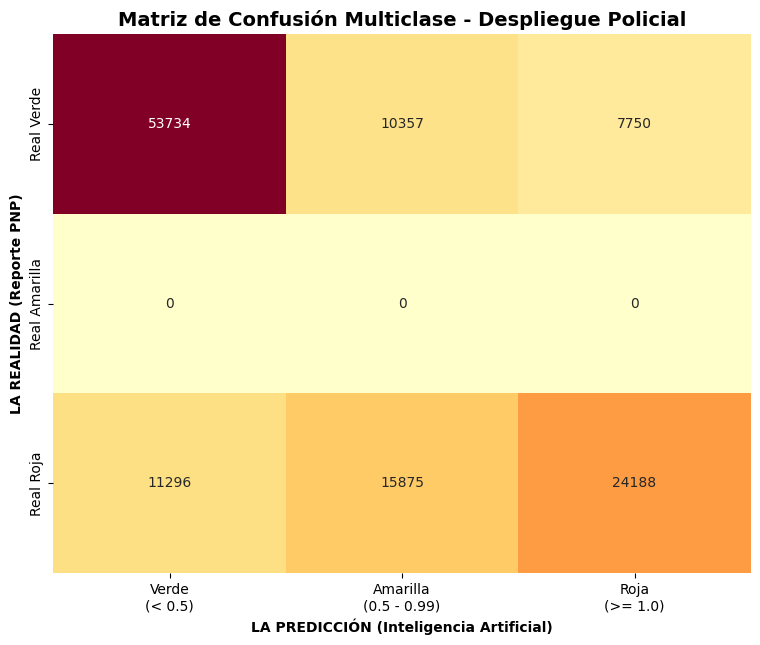


--- REPORTE DE INTELIGENCIA ESTRATÉGICA (MÉTRICAS) ---
                 precision    recall  f1-score   support

   Alerta Verde       0.83      0.75      0.79     71841
Alerta Amarilla       0.00      0.00      0.00         0
    Alerta Roja       0.76      0.47      0.58     51359

       accuracy                           0.63    123200
      macro avg       0.53      0.41      0.46    123200
   weighted avg       0.80      0.63      0.70    123200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# ==============================================================================
# CELDA 8: EXAMEN FINAL (MATRIZ MULTICLASE - SEMÁFORO DE RIESGO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

print("Iniciando Fase de Examen Operativo (Semáforo de Riesgo PNP)...")

modelo_gnn.eval() # Apagamos el aprendizaje
predicciones_lista = []

# 1. Predicciones por lotes
with torch.no_grad():
    for i in range(0, len(X_test_norm), 32):
        X_batch = X_test_norm[i : i + 32]
        pred_batch = modelo_gnn(X_batch, edge_index, edge_weights)
        predicciones_lista.append(pred_batch)

prediccion_test = torch.cat(predicciones_lista, dim=0)

# 2. Des-normalizar a la escala real de delitos
pred_real = scaler_Y.inverse_transform(prediccion_test.numpy().reshape(-1, 1)).flatten()
y_test_real = scaler_Y.inverse_transform(Y_test_norm.numpy().reshape(-1, 1)).flatten()

# 3. APLICAR TU REGLA DE NEGOCIO (El Semáforo)
# Usamos np.select para clasificar en 3 niveles (0: Verde, 1: Amarilla, 2: Roja)
condiciones_pred = [pred_real < 0.5, (pred_real >= 0.5) & (pred_real < 1.0)]
condiciones_real = [y_test_real < 0.5, (y_test_real >= 0.5) & (y_test_real < 1.0)]
opciones = [0, 1]

# Si no cumple ni Verde ni Amarilla, por defecto es Roja (2)
pred_clases = np.select(condiciones_pred, opciones, default=2)
y_test_clases = np.select(condiciones_real, opciones, default=2)

# 4. Generar la Matriz de Confusión 3x3
cm = confusion_matrix(y_test_clases, pred_clases)

# 5. Dibujar el Gráfico
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd", cbar=False,
            xticklabels=['Verde\n(< 0.5)', 'Amarilla\n(0.5 - 0.99)', 'Roja\n(>= 1.0)'],
            yticklabels=['Real Verde', 'Real Amarilla', 'Real Roja'])

plt.ylabel('LA REALIDAD (Reporte PNP)', fontweight='bold')
plt.xlabel('LA PREDICCIÓN (Inteligencia Artificial)', fontweight='bold')
plt.title('Matriz de Confusión Multiclase - Despliegue Policial', fontsize=14, fontweight='bold')
plt.show()

print("\n" + "="*60)
print("--- REPORTE DE INTELIGENCIA ESTRATÉGICA (MÉTRICAS) ---")
print("="*60)
print(classification_report(y_test_clases, pred_clases, target_names=['Alerta Verde', 'Alerta Amarilla', 'Alerta Roja']))

Iniciando Fase de Evaluación Binaria (Para el documento de Tesis)...


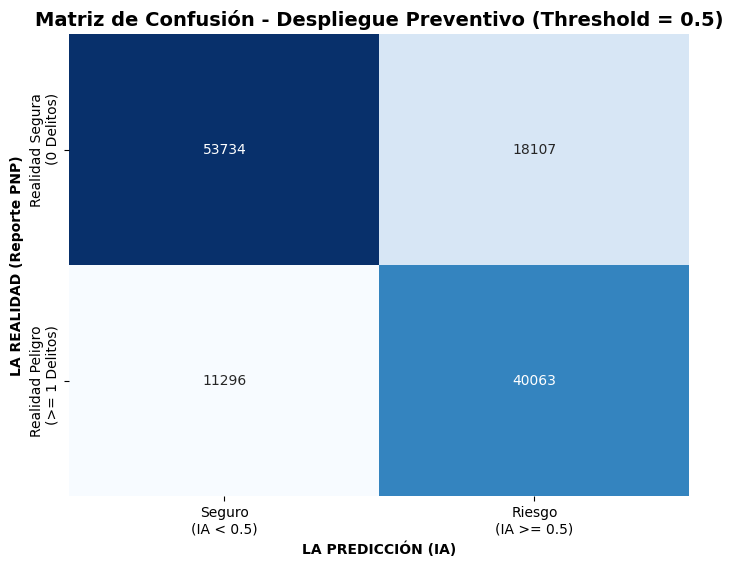


--- REPORTE DE MÉTRICAS ACADÉMICAS (TESIS) ---
                precision    recall  f1-score   support

   Zona Segura       0.83      0.75      0.79     71841
Zona de Riesgo       0.69      0.78      0.73     51359

      accuracy                           0.76    123200
     macro avg       0.76      0.76      0.76    123200
  weighted avg       0.77      0.76      0.76    123200



In [11]:
# ==============================================================================
# CELDA 8: EXAMEN FINAL Y MATRIZ DE CONFUSIÓN BINARIA (EVALUACIÓN ACADÉMICA)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

print("Iniciando Fase de Evaluación Binaria (Para el documento de Tesis)...")

modelo_gnn.eval() # Apagamos el aprendizaje
predicciones_lista = []

# 1. Predicciones por lotes
with torch.no_grad():
    for i in range(0, len(X_test_norm), 32):
        X_batch = X_test_norm[i : i + 32]
        pred_batch = modelo_gnn(X_batch, edge_index, edge_weights)
        predicciones_lista.append(pred_batch)

prediccion_test = torch.cat(predicciones_lista, dim=0)

# 2. Des-normalizar a la escala real de delitos
pred_real = scaler_Y.inverse_transform(prediccion_test.numpy().reshape(-1, 1)).flatten()
y_test_real = scaler_Y.inverse_transform(Y_test_norm.numpy().reshape(-1, 1)).flatten()

# 3. APLICAR LÓGICA BINARIA (Riesgo vs. No Riesgo)
UMBRAL = 0.5 # A partir de 0.5, la IA ya está detectando anomalías y amerita patrullaje

# Realidad: 0 (Verde/No Delito) | >= 1 (Roja/Hubo Delito)
y_test_clases = (y_test_real >= 1.0).astype(int)
# Predicción: < 0.5 (Verde/Tranquilo) | >= 0.5 (Roja/Riesgo Detectado)
pred_clases = (pred_real >= UMBRAL).astype(int)

# 4. Generar la Matriz de Confusión 2x2
cm = confusion_matrix(y_test_clases, pred_clases)

# 5. Dibujar el Gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Seguro\n(IA < 0.5)', 'Riesgo\n(IA >= 0.5)'],
            yticklabels=['Realidad Segura\n(0 Delitos)', 'Realidad Peligro\n(>= 1 Delitos)'])

plt.ylabel('LA REALIDAD (Reporte PNP)', fontweight='bold')
plt.xlabel('LA PREDICCIÓN (IA)', fontweight='bold')
plt.title('Matriz de Confusión - Despliegue Preventivo (Threshold = 0.5)', fontsize=14, fontweight='bold')
plt.show()

print("\n" + "="*60)
print("--- REPORTE DE MÉTRICAS ACADÉMICAS (TESIS) ---")
print("="*60)
print(classification_report(y_test_clases, pred_clases, target_names=['Zona Segura', 'Zona de Riesgo']))